In [16]:
import sys 
import os 
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from fitting import sigmoid
from analysis_of_simulation_result import * 
import matplotlib.pyplot as plt
from make_network import *
sez_ids = np.concatenate(list(sez.values()))
sez_id2g = {f:g for g,fid in sez.items() for f in fid}

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 10



In [34]:
# data_df_tarsal = data_df_tarsal.drop('control')
# data_df_labial = data_df_labial.drop('control')

In [45]:
fitting_result_path = Path(REPO_ROOT/'figure4/figure4F-K.MN9_PER_fitting')
params_opt_tarsal = pickle.load(open(fitting_result_path/'fitting_result/tarsal/result_av1a1_170.pkl','rb'))
params_opt_labial = pickle.load(open(fitting_result_path/'fitting_result/labial/result_av1a1_170.pkl','rb'))
V_l1l2,K_l1l2,n_l1l2,V_l3,K_l3,n_l3,k_act_L,r0_L,h_L = params_opt_labial.x
V_at,K_at,n_at,V_tp,K_tp,n_tp,k_act_T,r0_T,h_T = params_opt_tarsal.x
popt_tarsal = [k_act_T,r0_T,h_T]
popt_labial = [k_act_L,r0_L,h_L]


data_df_labial = pd.read_parquet('simulation_data/simulation_data_labial.parquet')
data_df_tarsal = pd.read_parquet('simulation_data/simulation_data_tarsal.parquet')


In [74]:
import numpy as np
import pandas as pd


def prepare_dataset(
    excel_path,
    data_df,
    control_values=None,
    rename_dict=None,
    drop_outliers=None,
    sheet_name=0,   # 추가
):

    # Load experimental data
    df = pd.read_excel(
        excel_path,
        index_col=0,
        sheet_name=sheet_name
    )

    lines = df.index.values.astype(str)

    # Mean per genotype
    df_mean = pd.DataFrame(columns=['exp:sugar', 'exp:sugar+geosmin'])

    for g in np.unique(lines):
        df_mean.loc[g] = [
            np.mean(df[lines == g]['exp:sugar'].values),
            np.mean(df[lines == g]['exp:sugar+geosmin'].values)
        ]

    # Rename indices
    if rename_dict is not None:
        df_mean.rename(index=rename_dict, inplace=True)

    # Add control
    if control_values is not None:
        control_sugar, control_geosmin = control_values
        df_mean.loc['control'] = [control_sugar, control_geosmin]

    # Merge simulation + experimental
    i1 = data_df.index.values
    i2 = df_mean.index.values

    all_df = pd.DataFrame(
        columns=[
            'simul:sugar',
            'simul:sugar+geosmin',
            'exp:sugar',
            'exp:sugar+geosmin'
        ]
    )

    for i in np.intersect1d(i1, i2):
        all_df.loc[i] = np.concatenate([
            data_df.loc[i].values,
            df_mean.loc[i].values
        ])

    # Remove outliers
    if drop_outliers is None:
        drop_outliers = []

    all_df_rm_outlier = all_df.drop(drop_outliers)

    # Flatten data
    x_data = np.concatenate([
        all_df_rm_outlier['simul:sugar'].values,
        all_df_rm_outlier['simul:sugar+geosmin'].values
    ])

    y_data = np.concatenate([
        all_df_rm_outlier['exp:sugar'].values,
        all_df_rm_outlier['exp:sugar+geosmin'].values
    ])

    return all_df, all_df_rm_outlier, x_data, y_data


rename_dict = {
    'FMin': 'FMIn',
    'meteor': 'meteor',
    'sink,sync': 'sink and sync'
}

# tarsal
all_df_atGRN, all_df_atGRN_rm_outlier, x_data_atGRN, y_data_atGRN = prepare_dataset(
    excel_path='data_fixed/tarsal_100mM.xlsx',
    sheet_name='non_fixed',
    data_df=data_df_tarsal,
    rename_dict=rename_dict,
    drop_outliers=[]
)

# tarsal fixed
all_df_atGRN_fixed, all_df_atGRN_rm_outlier_fixed, x_data_atGRN_fixed, y_data_atGRN_fixed = prepare_dataset(
    excel_path='data_fixed/tarsal_100mM.xlsx',
    sheet_name='fixed',
    data_df=data_df_tarsal,
    rename_dict=rename_dict,
    drop_outliers=[]
)


# labial
all_df_labial, all_df_labial_rm_outlier, x_data_labial, y_data_labial = prepare_dataset(
    excel_path='data_fixed/labial_100mM.xlsx',
    sheet_name='non_fixed',
    data_df=data_df_labial,
    control_values=(0.675, 0.675),
    rename_dict=rename_dict,
    drop_outliers=[]
)

# labial
all_df_labial_fixed, all_df_labial_rm_outlier_fixed, x_data_labial_fixed, y_data_labial_fixed = prepare_dataset(
    excel_path='data_fixed/labial_100mM.xlsx',
    sheet_name='fixed',
    data_df=data_df_labial,
    control_values=(0.675, 0.675),
    rename_dict=rename_dict,
    drop_outliers=[]
)



In [75]:
from scipy.stats import linregress
def plot_screening_split_condition(
    df,
    popt,
    exp_scale,
    fit_scale,
    condition='sugar',   
    target=('FMIn', 'meteor'),
    label_condition=None,
    cell2color=None,
    marker='o',
    ax= None,
    fontsize=10,
    ps=25,
    lw=0.5):
    
    import numpy as np
    import matplotlib.pyplot as plt
    import distinctipy

    if cell2color is None:
        import distinctipy
        colors = distinctipy.get_colors(len(cells))
        cell2color = dict(zip(cells, colors))
        
    cells = df.index.values   # 🔥 이 줄 추가

    order_idx = np.arange(len(cells))
    target_idx = np.where(np.isin(cells, target))[0]

    wanted_order = np.concatenate([
        order_idx[~np.isin(order_idx, target_idx)],
        target_idx
    ])
    # 🔥 condition별 데이터 선택
    if condition == 'sugar':
        x_data = sigmoid(df['simul:sugar'].values,*popt)
        y_data = df['exp:sugar'].values
    elif condition == 'sugar+geosmin':
        x_data = sigmoid(df['simul:sugar+geosmin'].values,*popt)
        y_data = df['exp:sugar+geosmin'].values
    else:
        raise ValueError("condition must be 'sugar' or 'sugar+geosmin'")


    for i in wanted_order:
        this_cell = cells[i]

        # label 여부
        if label_condition is None:
            show_label = True
        else:
            show_label = label_condition(x_data, y_data, i)

        marker = marker#'o' if this_cell in target else 'o'

        kwargs = dict(
            color=cell2color[this_cell],
            s=ps,
            linewidths=lw,
            marker=marker,
            edgecolor='black'
        )

        if show_label:
            kwargs['label'] = this_cell

        ax.scatter(x_data[i], y_data[i], **kwargs)


    all_data = np.concatenate([x_data, y_data])
    data_min = np.nanmin(all_data)
    data_max = np.nanmax(all_data)
    
    margin = (data_max - data_min) * 0.05
    limit_range = np.arange(0,1.1,.1)#[data_min - margin, data_max + margin]
        
    mask = ~np.isnan(x_data) & ~np.isnan(y_data)
    x_clean, y_clean = x_data[mask], y_data[mask]
    
    ax.spines[['top', 'right']].set_visible(False)

    return {
        'cells': cells,
        'x': x_data,
        'y': y_data,
        'condition': condition
    }


def plot_regression_line(res,ax):
    
    x_target = res['x']
    y_target = res['y']


    slope_all, intercept_all, r_all, p_all, _ = linregress(x_target, y_target)
    
    xfit = np.linspace(np.nanmin(x_target), np.nanmax(x_target), 100)
    yfit_all = slope_all * xfit + intercept_all
    
    ax.plot(
        xfit, yfit_all,
        linestyle='--', color='gray', alpha=0.6,
        linewidth=1.5, zorder=1, label=f'All (r={r_all:.2f})'
    )

    stats_text = f'r= {r_all:.3f}'

    return r_all

def plot_identity_error(res, ax,plot=False):
    import numpy as np
    import pandas as pd

    x_target = np.asarray(res['x'])
    y_target = np.asarray(res['y'])

    # 
    valid = ~(np.isnan(x_target) | np.isnan(y_target))
    x_target = x_target[valid]
    y_target = y_target[valid]
    valid_cells = res['cells'][valid]  # 유효한 cell 이름 매칭용


    vertical_error = y_target - x_target

    #
    # 
    orthogonal_error = vertical_error / np.sqrt(2)
    abs_orthogonal_error = np.abs(orthogonal_error)
    sq_orthogonal_error = orthogonal_error**2
    
    # 
    rmse_orthogonal = np.sqrt(np.mean(sq_orthogonal_error))
    
    # 3. Identity line (y=x) 
    lim_max = max(np.max(x_target), np.max(y_target))
    
    if plot == True:
        ax.plot(
            [0, lim_max],
            [0, lim_max],
            linestyle='--',
            color='gray',
            alpha=0.6,
            linewidth=1.5,
            zorder=1,
            label=f'y=x (Geo_RMSE={rmse_orthogonal:.2f})'
        )

    error_df = pd.DataFrame({
        'x': x_target,
        'y': y_target,
        'vertical_error': vertical_error,            #
        'orthogonal_error': orthogonal_error,        #
        'abs_orthogonal_error': abs_orthogonal_error, # 
        'sq_orthogonal_error': sq_orthogonal_error    # 
    })

    error_df.index = valid_cells
    error_df.index.name = 'neuron'

    return rmse_orthogonal, error_df


In [72]:
import distinctipy
colors = distinctipy.get_colors(len(sez))
with open(f'{os.getcwd()}/assigned_colors_sez_neuron.pkl','rb') as f:
    cell2color = pickle.load(f)
cell2color['sink and sync'] = '#399918'
cell2color['FMIn'] = cell2color['FMin']

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

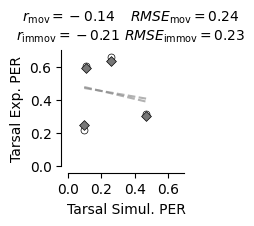

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


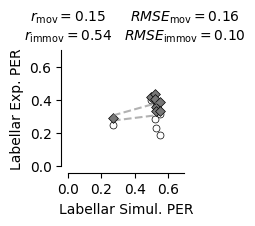

In [73]:
# axes_flat = axes.flatten()
all_df = {'tarsal':all_df_atGRN.drop('meteor'),'labial':all_df_labial.drop('meteor')}
all_df_fixed = {'tarsal':all_df_atGRN_fixed.drop('meteor'),'labial':all_df_labial_fixed.drop('meteor')}
popt = {'tarsal':popt_tarsal,'labial':popt_labial}
control_suc_exp = {'sugar':{'tarsal':0.625,'labial':0.675},'sugar+geosmin': {'tarsal':0.291666666666667,'labial':0.675}}

control_suc_simul = {'sugar':{'tarsal':0.4529442,'labial':0.578978}, 'sugar+geosmin':{'tarsal':0.24477219,'labial':0.47638793}}



i = 0
for site in ['tarsal','labial']:
    

    for cond in ['sugar']:#,'sugar+geosmin'
        fig,ax = plt.subplots(1,1,figsize=(1.5,1.5))
#         ax = axes_flat[i]
        res = plot_screening_split_condition(
            all_df[site],
            popt[site],
            control_suc_exp[cond][site],
            control_suc_simul[cond][site],
            ax=ax,
            condition=cond,
            cell2color={x:'#ffffff' for x in cell2color.keys()},
            marker='o'
        )
        r1 = plot_regression_line(res,ax)
        r1_, error_df = plot_identity_error(res, ax)
        
        
        res = plot_screening_split_condition(
            all_df_fixed[site],
            popt[site],
            control_suc_exp[cond][site],
            control_suc_simul[cond][site],
            ax=ax,
            condition=cond,
            cell2color={x:'#777777' for x in cell2color.keys()},
            marker='D'
        )
        r2 = plot_regression_line(res,ax)
        r2_, error_df = plot_identity_error(res, ax)
        text = (fr'$r_{{\mathrm{{mov}}}} = {r1:.2f}$' + '\n' + fr'$r_{{\mathrm{{immov}}}} = {r2:.2f}$')
        text2 = (fr'$RMSE_{{\mathrm{{mov}}}} = {r1_:.2f}$' + '\n' + fr'$RMSE_{{\mathrm{{immov}}}} = {r2_:.2f}$')
        ax.text(
            0, 1.05,
            text,
            transform=ax.transAxes,
            ha='center',
            va='bottom',
            clip_on=False
        )

        ax.text(
            1, 1.05,
            text2,
            transform=ax.transAxes,
            ha='center',
            va='bottom',
            clip_on=False
        )
        ax.set_xticks(list(np.arange(0,.8,.2)))
        ax.set_yticks(list(np.arange(0,.8,.2)))
        ax.set_xlim([0,.7])
        ax.set_ylim([0,.7])
        if site=='labial':
            site = 'labellar'
        ax.set_ylabel(f'{site.capitalize()} Exp. PER')
        ax.set_xlabel(f'{site.capitalize()} Simul. PER')
        i += 1 

        ax.spines['left'].set_position(('outward', 5))
        ax.spines['bottom'].set_position(('outward', 5))
#         plt.savefig(f'{site}_{cond}.svg',bbox_inches='tight')